## Loading Results

In [1]:
import json
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results = pd.read_json('results.json')

In [78]:
def calc_avg_sample_prob(df, task, experiment, p, q, metric = 'f1'):
    """
    Calculate the average metric for a given task and experiment.
    """
    task_df = df[(df['task'] == task) & (df['experiment_name'] == experiment) & (df['edge_sampling_prob'] == p) & (df['null_sampling_prob'] == q)]
    return task_df[metric].mean(), task_df[metric].std()

def calc_avg_agreement_threshold(df, task, experiment, threshold, metric = 'f1'):
    """
    Calculate the average agreement threshold for a given task and experiment.
    """
    task_df = df[(df['task'] == task) & (df['experiment_name'] == experiment) & (df['agreement_threshold'] == threshold)]
    return task_df[metric].mean(), task_df[metric].std()

def plot_task_results(df, task, res_dict, title, xlabel, ylabel, rotation=0):
    """
    Plot the results for a given task and result dict.
    """
    _, ax = plt.subplots(figsize=(8, 4))
    ticks_len = len(res_dict)
    means = [res_dict[k][0] for k in res_dict.keys()]
    stds = [res_dict[k][1] for k in res_dict.keys()]
    # plot means
    ax.bar(res_dict.keys(), means, width=0.5, label='F1 Score', color='blue')
    # add 1 std range
    for i, k in enumerate(res_dict.keys()):
        ax.errorbar(k, means[i], yerr=stds[i], fmt='o', color='black', capsize=5)
    ax.set_xticks(np.arange(ticks_len), list(res_dict.keys()), rotation=rotation)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.show()
    

In [79]:
results.head(5)

,experiment_name,task,seed,edge_sampling_prob,null_sampling_prob,agreement_threshold,encoding_model,encoding_lr,encoding_epochs,gnn_model,gnn_agg_type,gnn_epochs,accuracy,f1
0,hetero_graph,Structured/iTunes-Amazon,21,0.005,0.001,0.85,roberta-base,0.00001,10,SAGE,sum,10,0.880734,0.734694
1,hetero_graph,Structured/iTunes-Amazon,42,0.005,0.001,0.85,roberta-base,0.00001,10,SAGE,sum,10,0.889908,0.769231
2,edge_sampling_probs,Structured/iTunes-Amazon,42,0.005,0.001,0.85,roberta-base,0.00001,10,SAGE,sum,10,0.889908,0.769231
3,edge_sampling_probs,Structured/iTunes-Amazon,21,0.005,0.001,0.85,roberta-base,0.00001,10,SAGE,sum,10,0.880734,0.734694
4,edge_sampling_probs,Structured/iTunes-Amazon,69,0.005,0.001,0.85,roberta-base,0.00001,10,SAGE,sum,10,0.899083,0.784314


## Analysis of Edge Sampling Probabilities

In [80]:
calc_avg_sample_prob(results, 'Structured/iTunes-Amazon', 'edge_sampling_probs_extended', 0.5, 0.1)

(0.7536506910456489, 0.015258717580570177)

In [81]:
short_tasks = ['Structured/iTunes-Amazon', 'Structured/Amazon-Google', 'Structured/Beer']
p_q_extended = [(0.005, 0.001), (0.01, 0.002), (0.05, 0.01), (0.1, 0.02), (0.5, 0.1)]
task_probs_dict = {}
for task in short_tasks:
    task_probs_dict[task] = {}
    for p, q in p_q_extended:
        avg_f1, std = calc_avg_sample_prob(results, task, 'edge_sampling_probs_extended', p, q)
        task_probs_dict[task][f'({p}, {q})'] = avg_f1, std


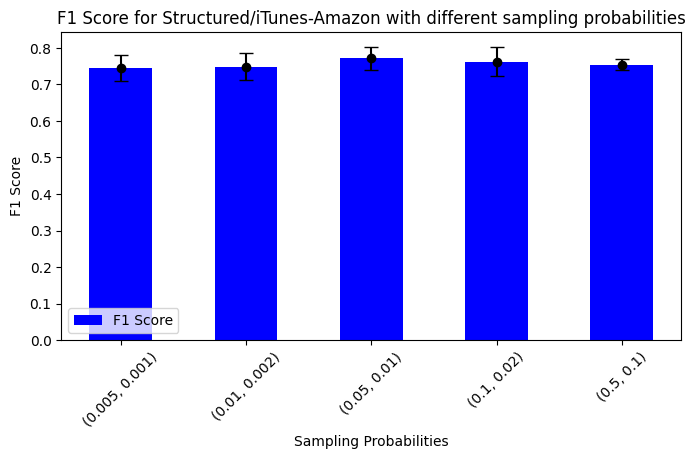

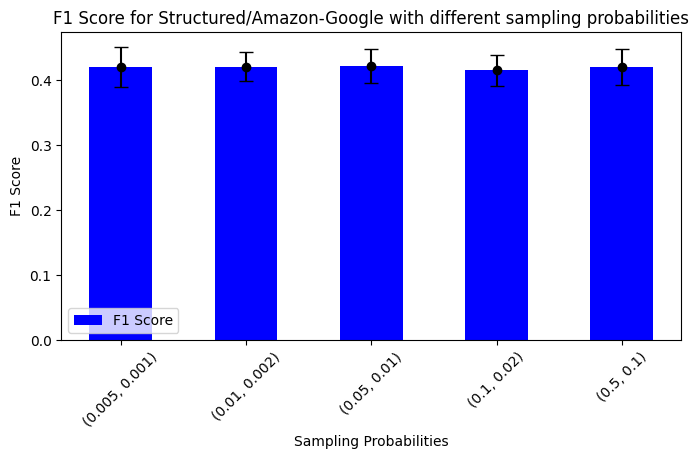

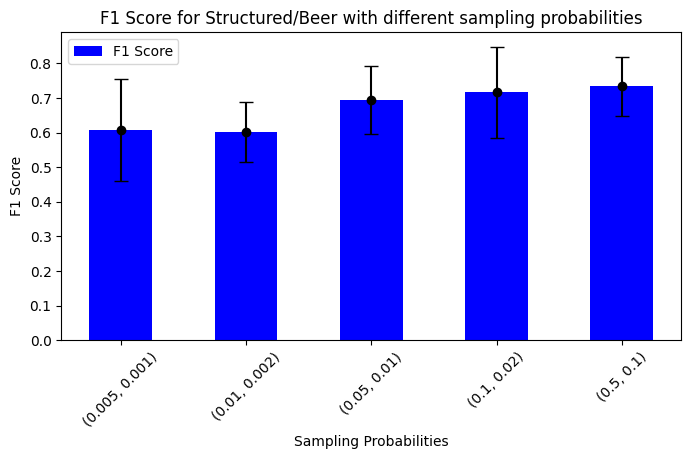

In [82]:
for task in short_tasks:
    plot_task_results(results, task, task_probs_dict[task], f'F1 Score for {task} with different sampling probabilities', 'Sampling Probabilities', 'F1 Score', rotation=45)

## Analyze Agreement Thresholds

In [90]:
tasks = ['Structured/iTunes-Amazon', 'Structured/Amazon-Google', 'Structured/DBLP-ACM', 'Structured/Beer', 'Textual/Abt-Buy']
agreement_thresholds = list(sorted(results['agreement_threshold'].unique()))
task_thresh_dict = {}
for task in tasks:
    task_thresh_dict[task] = {}
    for threshold in agreement_thresholds:
        avg_f1, std = calc_avg_agreement_threshold(results, task, 'agreement_threshold_expr', threshold)
        task_thresh_dict[task][f'{threshold:.2f}'] = avg_f1, std


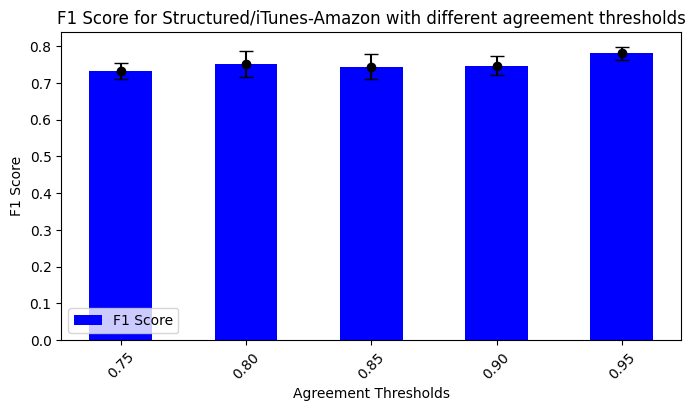

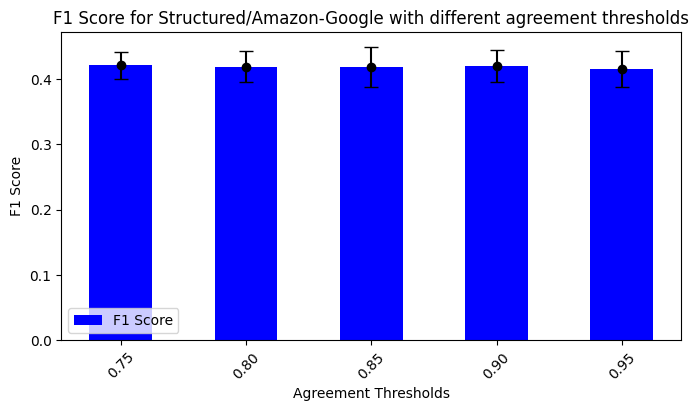

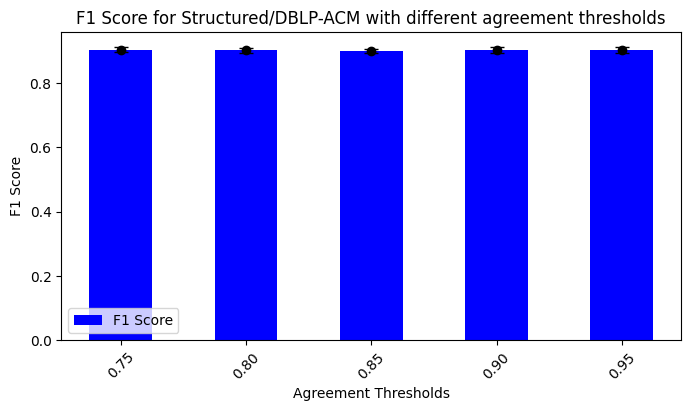

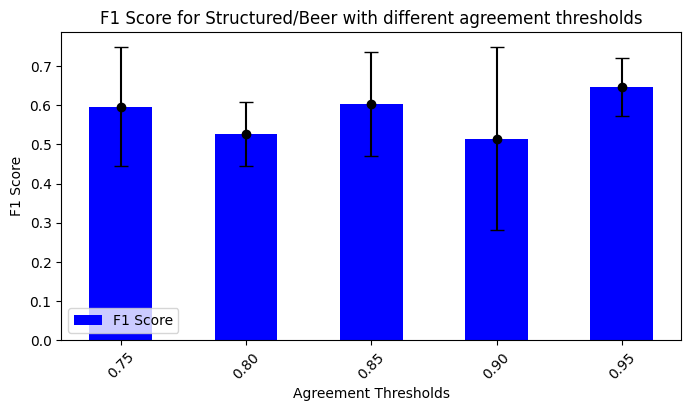

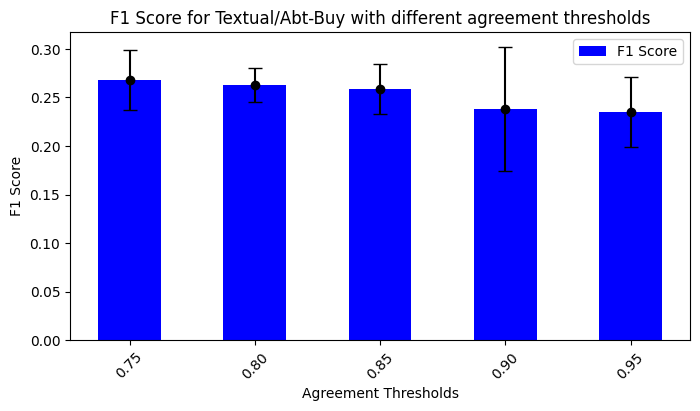

In [92]:
for task in tasks:
    plot_task_results(results, task, task_thresh_dict[task], f'F1 Score for {task} with different agreement thresholds', 'Agreement Thresholds', 'F1 Score', rotation=45)